#### Test plotting functions using the H2H2 data.

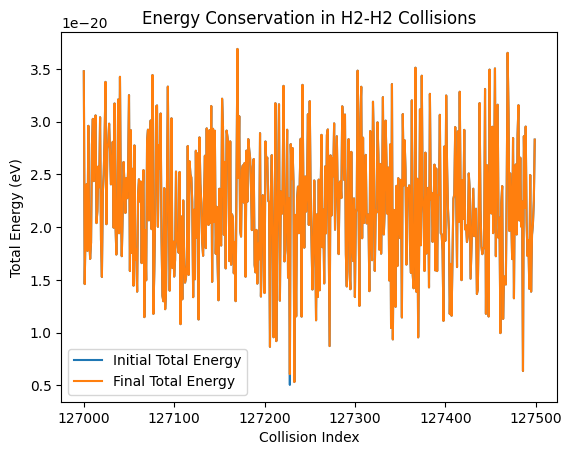

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
# Check energy conservation
file = "ctc_benjamin/H2H2_collisions.csv"
df = pd.read_csv(file, skiprows=1)
Etot_init = df.iloc[:,0] + df.iloc[:,1] + df.iloc[:,2]
Etot_final = df.iloc[:,3] + df.iloc[:,4] + df.iloc[:,5]
plt.plot(Etot_init, label='Initial Total Energy')
plt.plot(Etot_final, label='Final Total Energy')
plt.xlabel('Collision Index')
plt.ylabel('Total Energy (eV)')
plt.title('Energy Conservation in H2-H2 Collisions')
plt.legend()
plt.show()


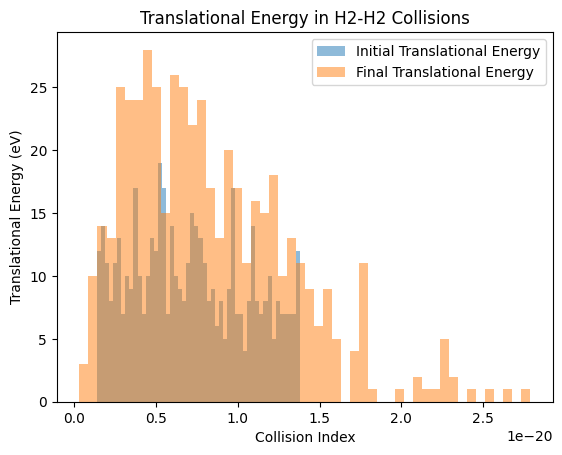

In [17]:
Etr_init = df.iloc[:,0]
Etr_final = df.iloc[:,3]
plt.hist(Etr_init, bins=50, alpha=0.5, label='Initial Translational Energy')
plt.hist(Etr_final, bins=50, alpha=0.5, label='Final Translational Energy')
plt.xlabel('Collision Index')
plt.ylabel('Translational Energy (eV)')
plt.title('Translational Energy in H2-H2 Collisions')
plt.legend()
plt.show()

In [ ]:
from visualization.plot import Plotter
from utils.helpers import load_dataset
from machinelearning.mdn_model import MixtureDensityNetwork
from machinelearning.gmm_model import GaussianMixtureModel
from config.experiment_config import ExperimentConfig
config = ExperimentConfig()

# Load CTC dataset
ctc_data = load_dataset("data/H2H2_collisions.csv")

# Sample MDN
mdn = MixtureDensityNetwork(input_dim=config.input_dim, output_dim=config.output_dim, num_mixtures=config.num_mixtures, hidden_dim=config.hidden_dim, randomseed=config.random_seed) 
mdn.load_model("results/models/mdn_H2H2.pth")
mdn_samples = mdn.sample(x=ctc_data[0])

# Sample GMM
gmm = GaussianMixtureModel(n_components=config.gmm_n_components, covariance_type=config.gmm_covariance_type)
gmm.fit(ctc_data[1])
gmm_samples = gmm.sample(num_samples=config.num_samples)

datasets = {
    "inputs": ctc_data[0][:,1:], # Use only the energy fractions for plotting not the total energy
    "CTC": ctc_data[1],
    "MDN": mdn_samples,
    "GMM": gmm_samples
}

Dataset contains 10000 rows


In [2]:
from visualization.plot import Plotter
from config.plotting_config import PlottingConfig
plotting_config = PlottingConfig()
plotter = Plotter(config=plotting_config)
plotter.plot_density_scatter(datasets=datasets)
plotter.plot_histogram(datasets=datasets)

In [3]:
from analysis.kl_divergence import kl_divergence

kl_ctc_mdn = kl_divergence(datasets["CTC"][0], datasets["MDN"][0])
kl_ctc_gmm = kl_divergence(datasets["CTC"][0], datasets["GMM"][0])
print(f"KL Divergence between CTC and MDN: {kl_ctc_mdn:.4f}")
print(f"KL Divergence between CTC and GMM: {kl_ctc_gmm:.4f}")

KL Divergence between CTC and MDN: -0.5497
KL Divergence between CTC and GMM: -0.4806


/home/tqz/Documents/University/Master Thesis/MEP_TijnZeelenberg/scatteringkernels/analysis/kl_divergence.py:17: UserWarning: reduction: 'mean' divides the total loss by both the batch size and the support size.'batchmean' divides only by the batch size, and aligns with the KL div math definition.'mean' will be changed to behave the same as 'batchmean' in the next major release.
  return kl_div(p, q, reduction='mean')


### DSMC testing

In [1]:
from physics.dsmc import DSMC_Simulation

Dsmc = DSMC_Simulation()

Dsmc.initialize_domain(box_size=10.0, nr_cells=10, boundary="specular")

Dsmc.initialize_particles(nr_molecules=1000, nr_particles=10, temperature=300.0)

print("cell_indices", Dsmc.cell_indices)

Dsmc.select_collision_pairs()


cell_indices [4 7 5 0 4 7 8 0 7 8]
particle_idx [3 7]
pairs []
particle_idx []
particle_idx []
particle_idx []
particle_idx [0 4]
pairs []
particle_idx [2]
particle_idx []
particle_idx [1 5 8]
pairs []
particle_idx [6 9]
pairs []
particle_idx []
